<a href="https://colab.research.google.com/github/shriver42/ESAA/blob/project/OB2%EC%A1%B0_%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OB2조 프로젝트(2) - Customer Segmentation

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

<a id="1"></a>
# <p style="background-color:#682F2F;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">1. IMPORTING LIBRARIES</p>

In [ ]:
#Importing the Libraries
import numpy as np
import pandas as pd
import datetime
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt, numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import AgglomerativeClustering
from matplotlib.colors import ListedColormap
from sklearn import metrics
import warnings
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")
np.random.seed(42)

<a id="2"></a>
# <p style="background-color:#682F2F;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">2. LOADING DATA</p>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Loading the dataset
data = pd.read_csv("/content/drive/MyDrive/OB2조/캐글_CustomerCluster/marketing_campaign.csv", sep="\t")
print("Number of datapoints:", len(data))
data.head()

Number of datapoints: 2240


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
#Information on features
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

#### **[데이터 전처리 필요 부분]**
* income에서 missing value 존재
* Dt_Customer: type이 DateTime이 아님
* 범주형 변수(features in dtype: object-Education,Marital_Status ): 인코딩 필요

In [ ]:
#To remove the NA values
data = data.dropna()
print("The total number of data-points after removing the rows with missing values are:", len(data))

The total number of data-points after removing the rows with missing values are: 2216


#### 날짜형 변수 처리: **"Dt_Customer"**
- datetime 으로 dtype 변환
- 가장 오래된 날짜와 가장 최신 날짜 추출

In [ ]:
# type 변환
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], format="%d-%m-%Y")
# 날짜 리스트
dates = []
for i in data["Dt_Customer"]:
    i = i.date()
    dates.append(i)

# 가장 초기/최근 고객의 등록일 추출
print("The newest customer's enrolment date in therecords:",max(dates))
print("The oldest customer's enrolment date in the records:",min(dates))

The newest customer's enrolment date in therecords: 2014-06-29
The oldest customer's enrolment date in the records: 2012-07-30


#### 파생변수 생성: **("Customer_For")**   
-> 고객 지속 기간: 가장 최근 날짜 기준으로 고객 신분 유지한 기간

In [ ]:
#Created a feature "Customer_For"
days = []
d1 = max(dates) #taking it to be the newest customer
for i in dates:
    delta = d1 - i
    days.append(delta)
data["Customer_For"] = days
data["Customer_For"] = pd.to_numeric(data["Customer_For"], errors="coerce")

#### **범주형 변수** 확인하기
- category 개수 확인
- category별 데이터 개수 확인



In [ ]:
print("Total categories in the feature Marital_Status:\n", data["Marital_Status"].value_counts(), "\n")
print("Total categories in the feature Education:\n", data["Education"].value_counts())

Total categories in the feature Marital_Status:
 Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 

Total categories in the feature Education:
 Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64


#### 변수 정리

- **나이(Age)** 추출: 2021-출생연도(Year_Birth)
- **소비한 총 금액(Spent)** 변수 생성: 모든 카테고리 소비 금액의 합계
- **Living_With** 변수 생성: Martial_Status 이용 -> 1인/2인 이상
- **총 자녀 수(Children)** 변수 생성: kids와 teenagers 수 합치기
- **"Family_Size"** 변수 생성: 가족 구성 명료화
- **"Is_Parent"** 변수 생성: 자식의 존재 여부
- **Education** 범주 구분을 3개로 단순화하기
- 중복된 칼럼 제거하기

In [ ]:
#Feature Engineering
#Age of customer today
data["Age"] = 2021-data["Year_Birth"]

#Total spendings on various items
data["Spent"] = data["MntWines"]+ data["MntFruits"]+ data["MntMeatProducts"]+ data["MntFishProducts"]+ data["MntSweetProducts"]+ data["MntGoldProds"]

#Deriving living situation by marital status"Alone"
data["Living_With"]=data["Marital_Status"].replace({"Married":"Partner", "Together":"Partner", "Absurd":"Alone", "Widow":"Alone", "YOLO":"Alone", "Divorced":"Alone", "Single":"Alone",})

#Feature indicating total children living in the household
data["Children"]=data["Kidhome"]+data["Teenhome"]

#Feature for total members in the householde
data["Family_Size"] = data["Living_With"].replace({"Alone": 1, "Partner":2})+ data["Children"]

#Feature pertaining parenthood
data["Is_Parent"] = np.where(data.Children> 0, 1, 0)

#Segmenting education levels in three groups
data["Education"]=data["Education"].replace({"Basic":"Undergraduate","2n Cycle":"Undergraduate", "Graduation":"Graduate", "Master":"Postgraduate", "PhD":"Postgraduate"})

#For clarity
data=data.rename(columns={"MntWines": "Wines","MntFruits":"Fruits","MntMeatProducts":"Meat","MntFishProducts":"Fish","MntSweetProducts":"Sweets","MntGoldProds":"Gold"})

#Dropping some of the redundant features
to_drop = ["Marital_Status", "Dt_Customer", "Z_CostContact", "Z_Revenue", "Year_Birth", "ID"]
data = data.drop(to_drop, axis=1)

<ipython-input-10-7ccaa6536fcb>:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Family_Size"] = data["Living_With"].replace({"Alone": 1, "Partner":2})+ data["Children"]


#### 최종 데이터 확인

In [ ]:
data.head()

,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,AcceptedCmp2,Complain,Response,Customer_For,Age,Spent,Living_With,Children,Family_Size,Is_Parent
0,Graduate,58138.0,0,0,58,635,88,546,172,88,...,0,0,1,57283200000000000,64,1617,Alone,0,1,0
1,Graduate,46344.0,1,1,38,11,1,6,2,1,...,0,0,0,9763200000000000,67,27,Alone,2,3,1
2,Graduate,71613.0,0,0,26,426,49,127,111,21,...,0,0,0,26956800000000000,56,776,Partner,0,2,0
3,Graduate,26646.0,1,0,26,11,4,20,10,3,...,0,0,0,12009600000000000,37,53,Partner,1,3,1
4,Postgraduate,58293.0,1,0,94,173,43,118,46,27,...,0,0,0,13910400000000000,40,422,Partner,1,3,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2216 non-null   object 
 1   Income               2216 non-null   float64
 2   Kidhome              2216 non-null   int64  
 3   Teenhome             2216 non-null   int64  
 4   Recency              2216 non-null   int64  
 5   Wines                2216 non-null   int64  
 6   Fruits               2216 non-null   int64  
 7   Meat                 2216 non-null   int64  
 8   Fish                 2216 non-null   int64  
 9   Sweets               2216 non-null   int64  
 10  Gold                 2216 non-null   int64  
 11  NumDealsPurchases    2216 non-null   int64  
 12  NumWebPurchases      2216 non-null   int64  
 13  NumCatalogPurchases  2216 non-null   int64  
 14  NumStorePurchases    2216 non-null   int64  
 15  NumWebVisitsMonth    2216 non-null   int64 

In [ ]:
data.describe()

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,...,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_For,Age,Spent,Children,Family_Size,Is_Parent
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2.216000e+03,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,...,0.064079,0.013538,0.009477,0.150271,3.054423e+16,52.179603,607.075361,0.947202,2.592509,0.714350
std,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,...,0.244950,0.115588,0.096907,0.357417,1.749036e+16,11.985554,602.900476,0.749062,0.905722,0.451825
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,25.000000,5.000000,0.000000,1.000000,0.000000
25%,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,1.555200e+16,44.000000,69.000000,0.000000,2.000000,0.000000
50%,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,...,0.000000,0.000000,0.000000,0.000000,3.071520e+16,51.000000,396.500000,1.000000,3.000000,1.000000
75%,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,...,0.000000,0.000000,0.000000,0.000000,4.570560e+16,62.000000,1048.000000,1.000000,3.000000,1.000000
max,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,6.039360e+16,128.000000,2525.000000,3.000000,5.000000,1.000000


The above stats show some discrepancies in mean Income and Age and max Income and age.

Do note that  max-age is 128 years, As I calculated the age that would be today (i.e. 2021) and the data is old.

I must take a look at the broader view of the data.
I will plot some of the selected features.

Reletive Plot Of Some Selected Features: A Data Subset


<Figure size 800x550 with 0 Axes>

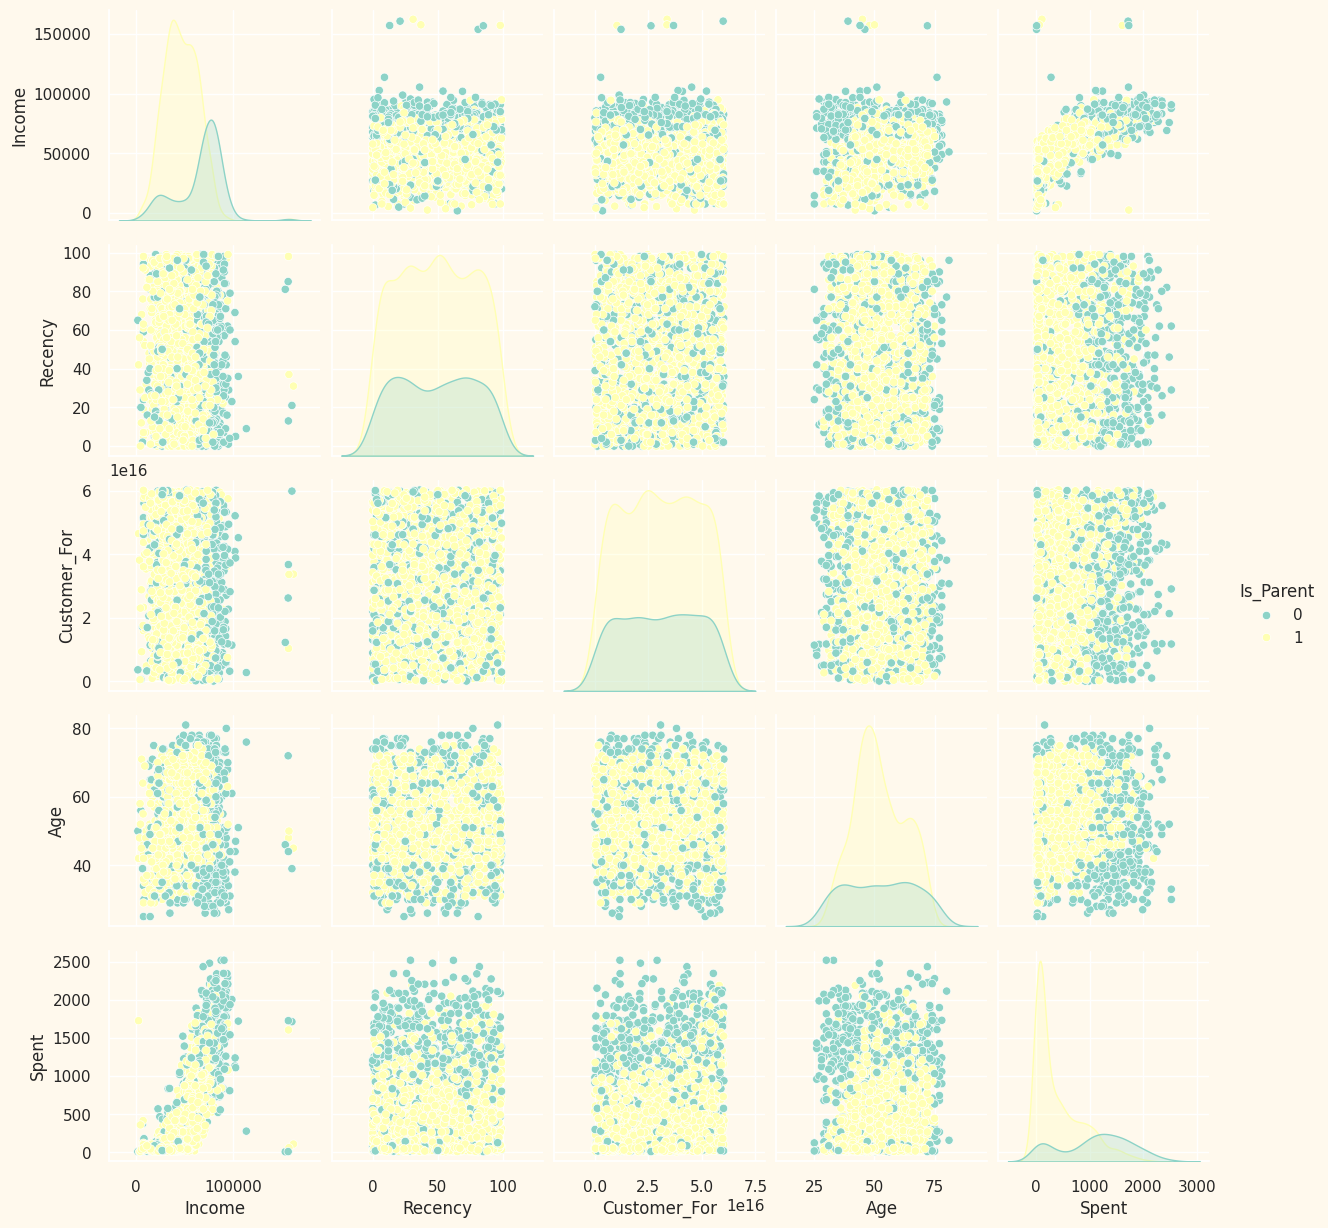

In [ ]:
cmap = "Set3"

# 그래프 그리려는 칼럼
To_Plot = [ "Income", "Recency", "Customer_For", "Age", "Spent", "Is_Parent"]
print("Reletive Plot Of Some Selected Features: A Data Subset")
plt.figure()
# 자식의 존재 여부에 따라 점 색 다름
sns.pairplot(data[To_Plot], hue= "Is_Parent",palette= ("Set3"))
#Taking hue
plt.show()

Income과 Age에 outlier 존재 -> 제거 필요

In [ ]:
#이상치 제거
data = data[(data["Age"]<90)]
data = data[(data["Income"]<600000)]
print("The total number of data-points after removing the outliers are:", len(data))

The total number of data-points after removing the outliers are: 2212


변수간 상관관계 확인: 범주형 변수는 제외

<Axes: >

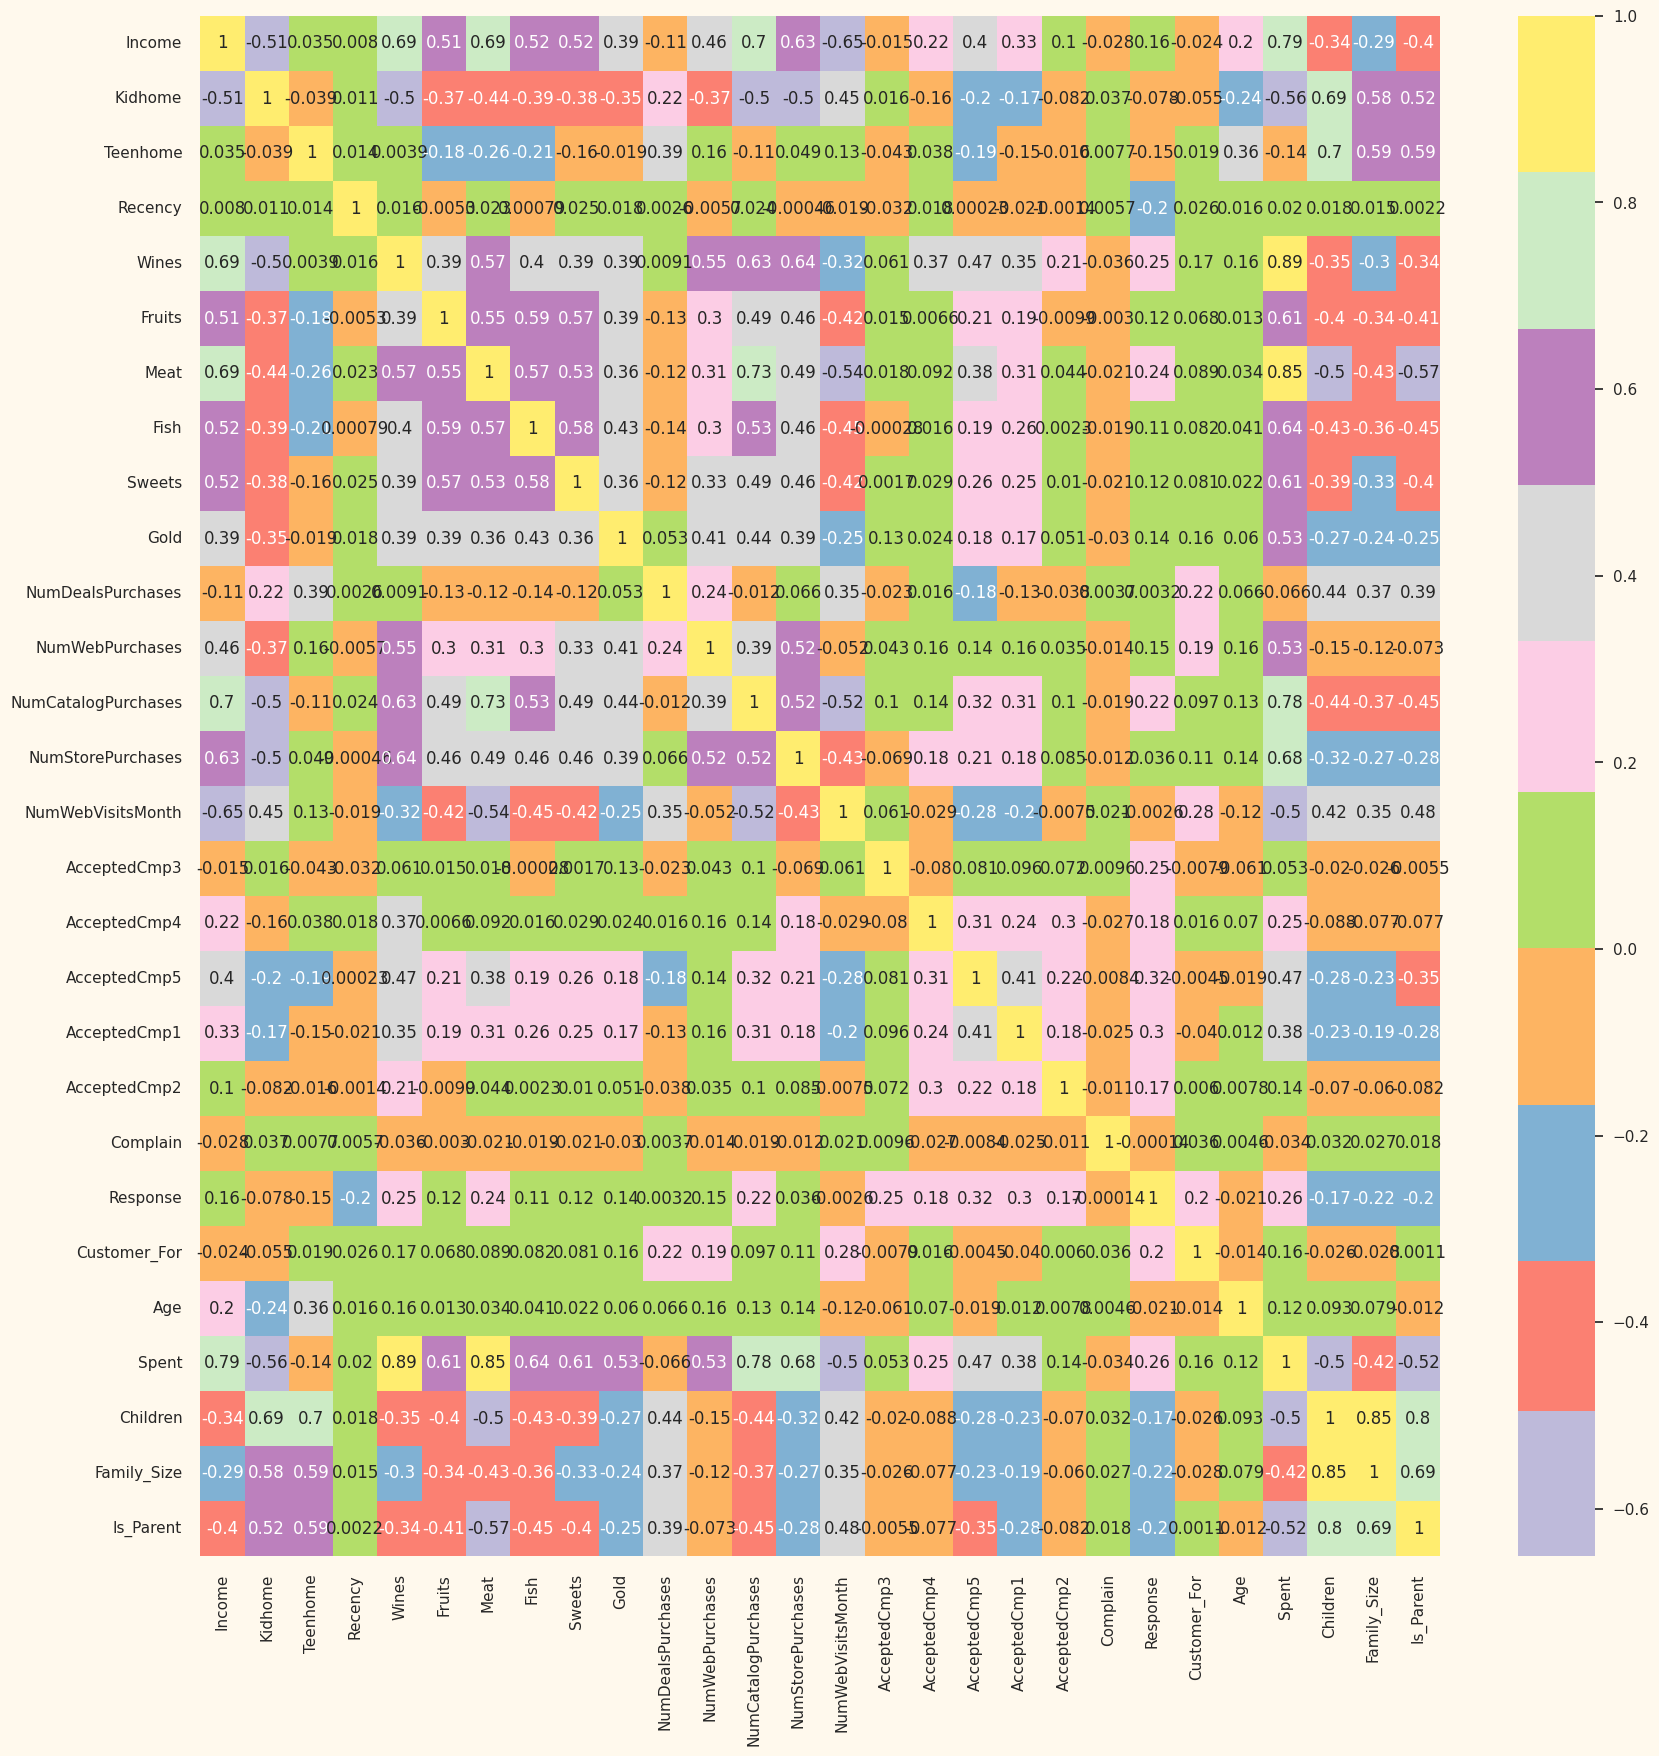

In [ ]:
#correlation matrix
quant = data.drop(['Education', 'Living_With'], axis = 1)
corrmat= quant.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corrmat,annot=True, cmap='Set3', center=0)

상관계수는 대체로 나쁘지 않은 편

<a id="4"></a>
# <p style="background-color:#682F2F;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">3. DATA PREPROCESSING</p>

**The following steps are applied to preprocess the data:**

- 범주형 변수 라벨 인코딩
- 정규화: StandardScaler
- 차원 축소를 위한 subset 생성

#### 범주형 데이터

In [ ]:
#Get list of categorical variables
s = (data.dtypes == 'object')
object_cols = list(s[s].index)

print("Categorical variables in the dataset:", object_cols)

Categorical variables in the dataset: ['Education', 'Living_With']


#### 라벨 인코딩

In [ ]:
#라벨 인코딩
LE=LabelEncoder()
for i in object_cols:
    data[i]=data[[i]].apply(LE.fit_transform)

print("라벨 인코딩 완료")

라벨 인코딩 완료


#### 정규화

In [ ]:

# 복사본 생성
ds = data.copy()
# 차원 축소를 위한 subset 생성: 정규화에 제외할 열 제거 -> 프로모션 관련 칼럼 및 datetime 변수
cols_del = ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2', 'Complain', 'Response']
ds = ds.drop(cols_del, axis=1)
# 정규화: StandardScaler()
scaler = StandardScaler()
scaler.fit(ds)
scaled_ds = pd.DataFrame(scaler.transform(ds),columns= ds.columns )
print("정규화 완료")

정규화 완료


In [ ]:
# 정규화된 데이터는 차원 축소에 활용
print("Dataframe to be used for further modelling:")
scaled_ds.head()

Dataframe to be used for further modelling:


,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Spent,Living_With,Children,Family_Size,Is_Parent
0,-0.893586,0.287105,-0.822754,-0.929699,0.310353,0.977660,1.552041,1.690293,2.453472,1.483713,...,2.503607,-0.555814,0.692181,1.527721,1.018352,1.676245,-1.349603,-1.264598,-1.758359,-1.581139
1,-0.893586,-0.260882,1.040021,0.908097,-0.380813,-0.872618,-0.637461,-0.718230,-0.651004,-0.634019,...,-0.571340,-1.171160,-0.132545,-1.189011,1.274785,-0.963297,-1.349603,1.404572,0.449070,0.632456
2,-0.893586,0.913196,-0.822754,-0.929699,-0.795514,0.357935,0.570540,-0.178542,1.339513,-0.147184,...,-0.229679,1.290224,-0.544908,-0.206048,0.334530,0.280110,0.740959,-1.264598,-0.654644,-1.581139
3,-0.893586,-1.176114,1.040021,-0.929699,-0.795514,-0.872618,-0.561961,-0.655787,-0.504911,-0.585335,...,-0.913000,-0.555814,0.279818,-1.060584,-1.289547,-0.920135,0.740959,0.069987,0.449070,0.632456
4,0.571657,0.294307,1.040021,-0.929699,1.554453,-0.392257,0.419540,-0.218684,0.152508,-0.001133,...,0.111982,0.059532,-0.132545,-0.951915,-1.033114,-0.307562,0.740959,0.069987,0.449070,0.632456


<a id="5"></a>
# <p style="background-color:#682F2F;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">4. DIMENSIONALITY REDUCTION</p>

- 여러 열들이 correlated(+중복) -> 분류하기 전, 차원 축소 필요

- **Principal component analysis (PCA)** 이용

    **Steps in this section:**
    * PCA로 차원축소
    * 축소된 데이터로 plot 그려보기

#### 차원축소(PCA)): 3차원

In [ ]:
#Initiating PCA to reduce dimentions aka features to 3
pca = PCA(n_components=3)
pca.fit(scaled_ds)
PCA_ds = pd.DataFrame(pca.transform(scaled_ds), columns=(["col1","col2", "col3"]))
PCA_ds.describe().T

,count,mean,std,min,25%,50%,75%,max
col1,2212.0,5.781993e-17,2.878602,-5.978124,-2.539470,-0.781595,2.386380,7.452915
col2,2212.0,6.424437e-17,1.709469,-4.194757,-1.323929,-0.173721,1.234851,6.168189
col3,2212.0,1.244735e-17,1.231687,-3.625248,-0.853713,-0.050842,0.863974,6.750458


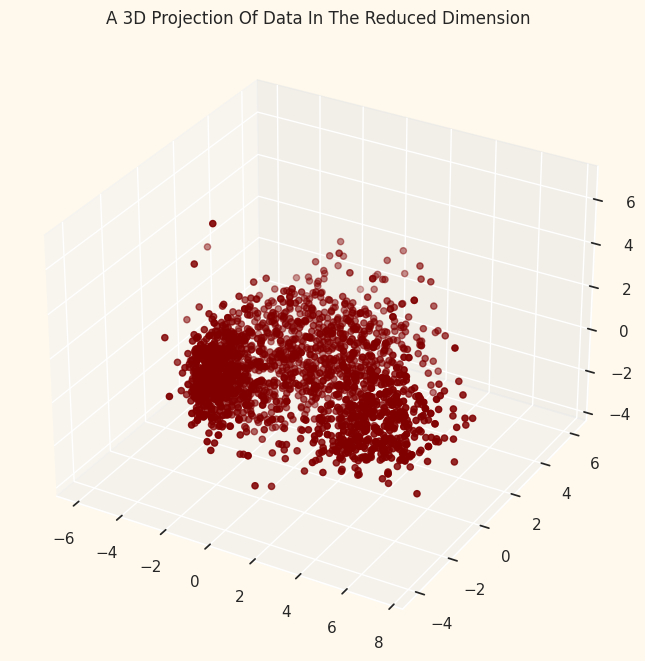

In [ ]:
#A 3D Projection Of Data In The Reduced Dimension
x =PCA_ds["col1"]
y =PCA_ds["col2"]
z =PCA_ds["col3"]
#To plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x,y,z, c="maroon", marker="o" )
ax.set_title("A 3D Projection Of Data In The Reduced Dimension")
plt.show()

<a id="6"></a>
# <p style="background-color:#682F2F;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">5. CLUSTERING : Agglomerative clustering</p>

- Agglomerative clustering is a hierarchical clustering method.  It involves merging examples until the desired number of clusters is achieved.

**Steps involved in the Clustering**
1. 최적 클러스터 수 결정: Elbow Method
2. Agglomerative Clustering 방법으로 군집화
3. 형성된 군집 확인하기: 산점도

#### 최적 클러스터 수 결정: Elbow Method
군집 수가 4개일 때, 최적

Elbow Method to determine the number of clusters to be formed:


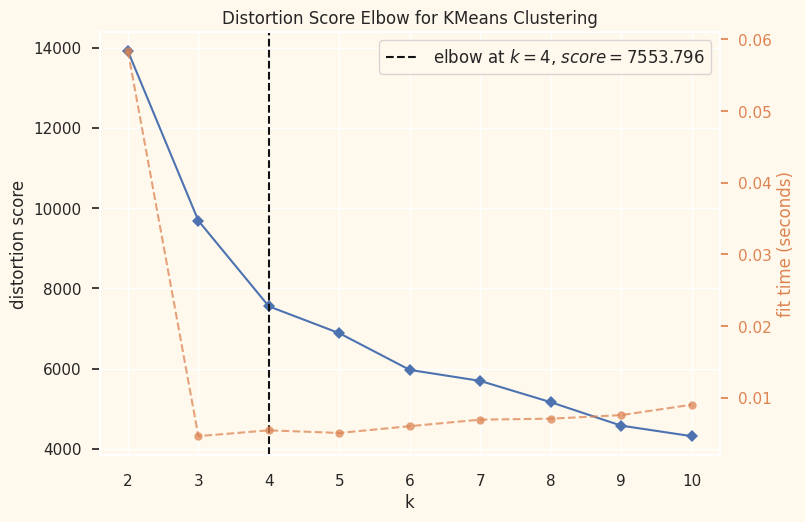

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
# Quick examination of elbow method to find numbers of clusters to make.
print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(KMeans(), k=10)
Elbow_M.fit(PCA_ds)
Elbow_M.show()

#### 군집화: Agglomerative Clustering Model

In [ ]:
#Initiating the Agglomerative Clustering model
AC = AgglomerativeClustering(n_clusters=4)
# fit model and predict clusters
yhat_AC = AC.fit_predict(PCA_ds)
PCA_ds["Clusters"] = yhat_AC
#Adding the Clusters feature to the orignal dataframe.
data["Clusters"]= yhat_AC

#### 군집 결과 확인: scatter plot

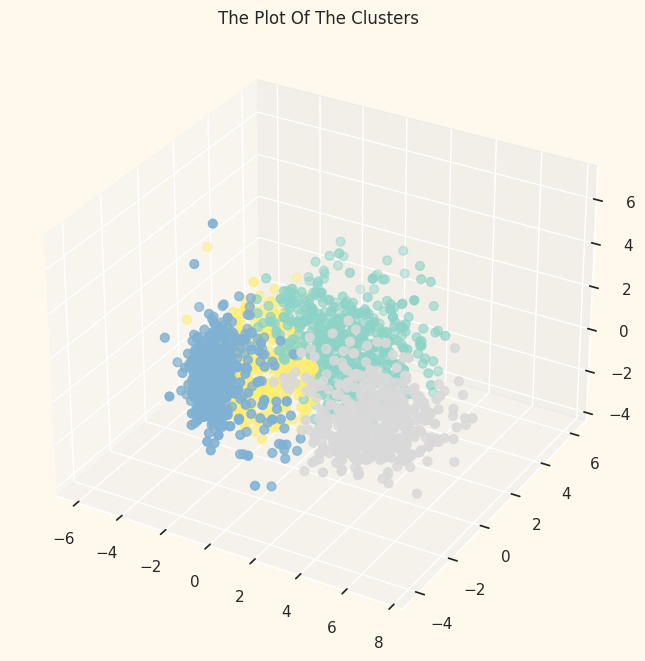

In [ ]:
#Plotting the clusters
fig = plt.figure(figsize=(10,8))
ax = plt.subplot(111, projection='3d', label="bla")
ax.scatter(x, y, z, s=40, c=PCA_ds["Clusters"], marker='o', cmap = cmap )
ax.set_title("The Plot Of The Clusters")
plt.show()

<a id="7"></a>
# <p style="background-color:#682F2F;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">6. EVALUATING MODELS</p>

**군집별 특성 파악**

#### 1. 군집의 분포 확인하기

<ipython-input-61-3483c8286d83>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl = sns.countplot(x=data["Clusters"], palette= pal)


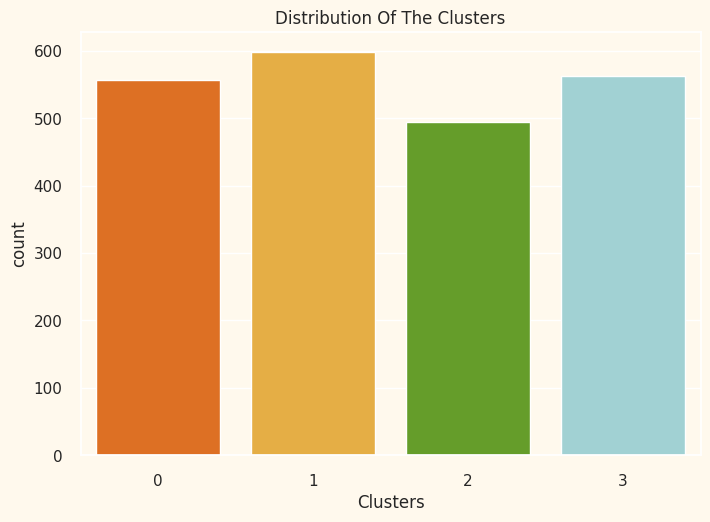

In [ ]:
#Plotting countplot of clusters
pal = ["#FC6B05","#FFB62B", "#65B017","#99D8DB"]
pl = sns.countplot(x=data["Clusters"], palette= pal)
pl.set_title("Distribution Of The Clusters")
plt.show()

4개의 군집별 데이터 수가 균등한 편

#### 2. **군집별 소비금액과 소득의 관계**
* group 0: high spending & average income
* group 1: high spending & high income
* group 2: low spending & low income
* group 3: high spending & low income  


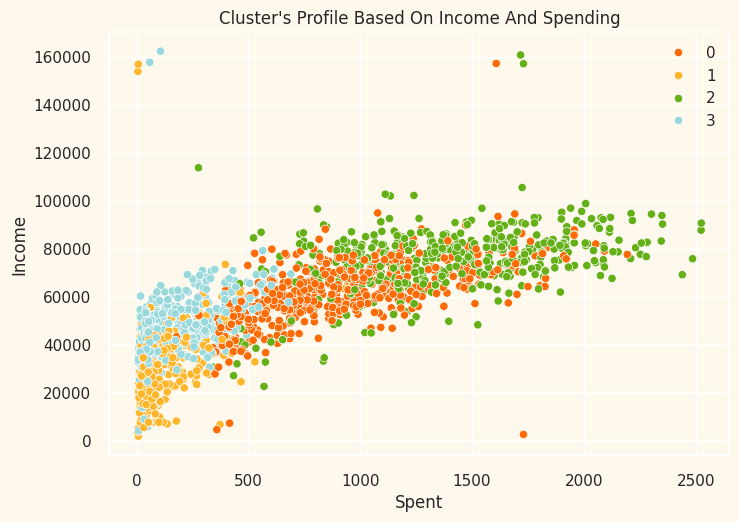

In [ ]:
pl = sns.scatterplot(data = data,x=data["Spent"], y=data["Income"],hue=data["Clusters"], palette= pal)
pl.set_title("Cluster's Profile Based On Income And Spending")
plt.legend()
plt.show()

#### 3. 군집별 소비금액 분포
: Wines, Fruits, Meat, Fish, Sweets and Gold 품목에 대한

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 14.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 71.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 56.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
<ipython-input-39-b5a4c0fdc6d1>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl=sns.boxenplot(x=data["Clusters"], y=data["Spent"], palette=pal)
/usr/local/lib/python3.10/dist-packages/seaborn/ca

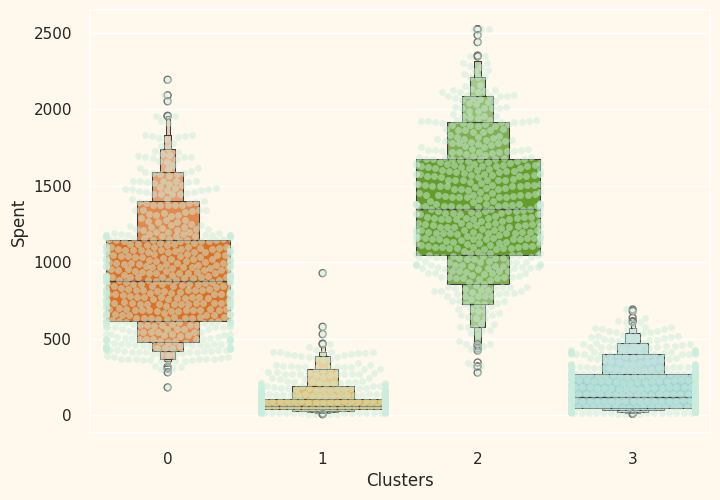

In [ ]:
plt.figure()
pl=sns.swarmplot(x=data["Clusters"], y=data["Spent"], color= "#CBEDDD", alpha=0.5 )
pl=sns.boxenplot(x=data["Clusters"], y=data["Spent"], palette=pal)
plt.show()

- 군집 2가 가장 큰 고객, 그 뒤는 군집 0이 따라옴
- 해당 카테고리에 대한 각 군집별 마케팅 전략 수립 가능

#### 군집별 프로모션 관리를 위한 분석

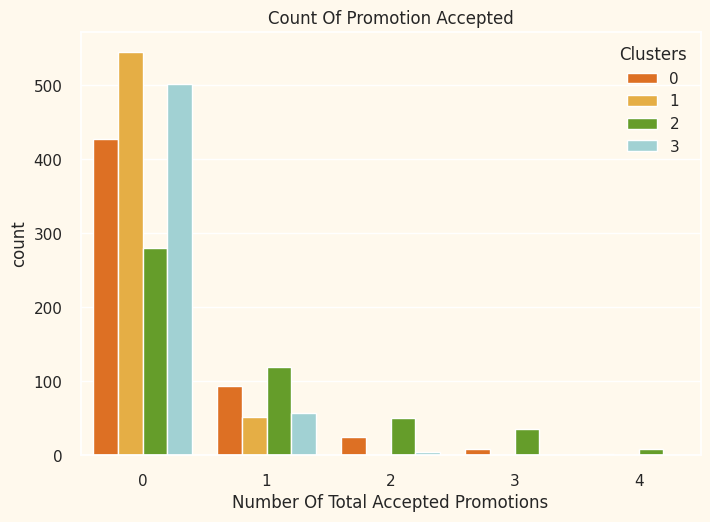

In [ ]:
#수락한 프로모션 갯수
data["Total_Promos"] = data["AcceptedCmp1"]+ data["AcceptedCmp2"]+ data["AcceptedCmp3"]+ data["AcceptedCmp4"]+ data["AcceptedCmp5"]
# 시각화
plt.figure()
pl = sns.countplot(x=data["Total_Promos"],hue=data["Clusters"], palette= pal)
pl.set_title("Count Of Promotion Accepted")
pl.set_xlabel("Number Of Total Accepted Promotions")
plt.show()

- 현재의 프로모션 성과는 크게 좋지 않음
- 모든 군집이 0에 가장 많이 분포

<ipython-input-41-0ef84d1c8fe9>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl=sns.boxenplot(y=data["NumDealsPurchases"],x=data["Clusters"], palette= pal)


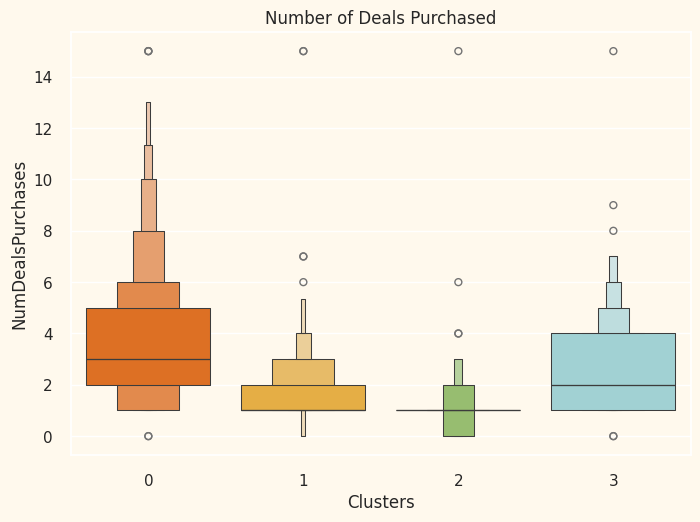

In [ ]:
#Plotting the number of deals purchased
plt.figure()
pl=sns.boxenplot(y=data["NumDealsPurchases"],x=data["Clusters"], palette= pal)
pl.set_title("Number of Deals Purchased")
plt.show()

- 프로모션 결과와 달리 거래 횟수는 괜찮음
    - cluster 0 and cluster 3에서 성과가 괜찮음 (이유는 모르겠음...)
    - cluster 1은 좋은 편은 아님
    - cluster 2를 끌어당길만한 것이 매우 부족해보임(제일 성과가 안좋다는 뜻)


<Figure size 800x550 with 0 Axes>

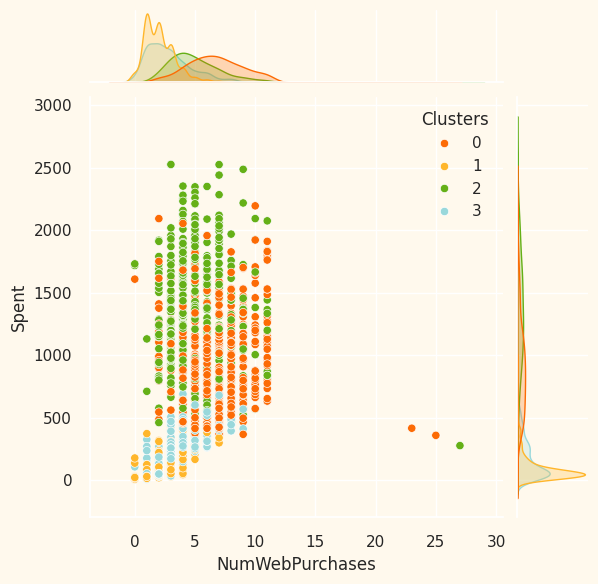

<Figure size 800x550 with 0 Axes>

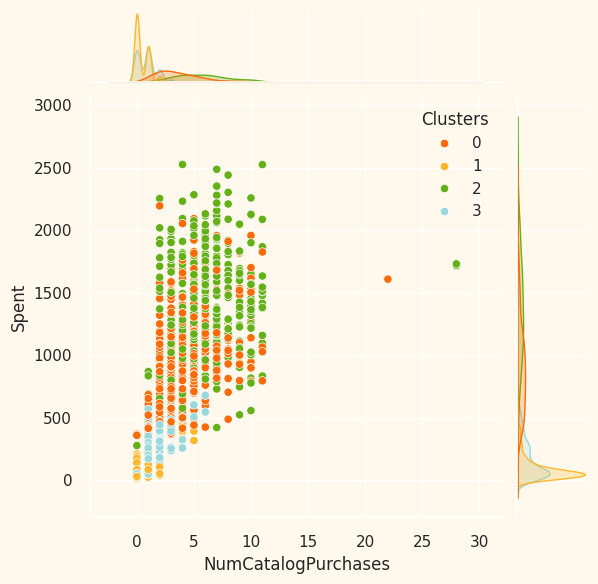

<Figure size 800x550 with 0 Axes>

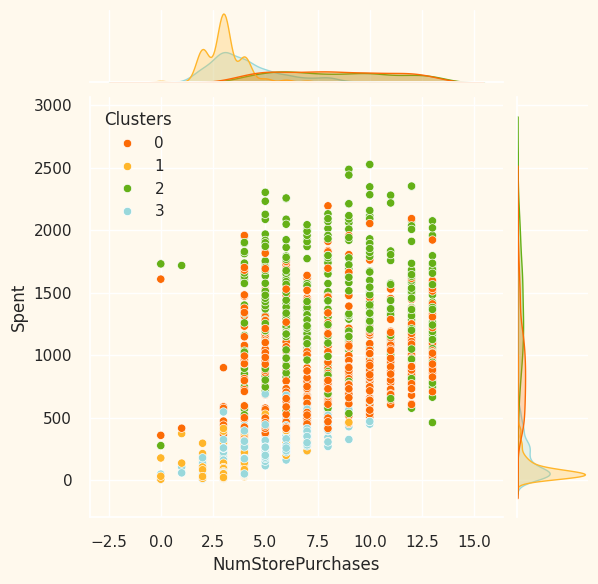

<Figure size 800x550 with 0 Axes>

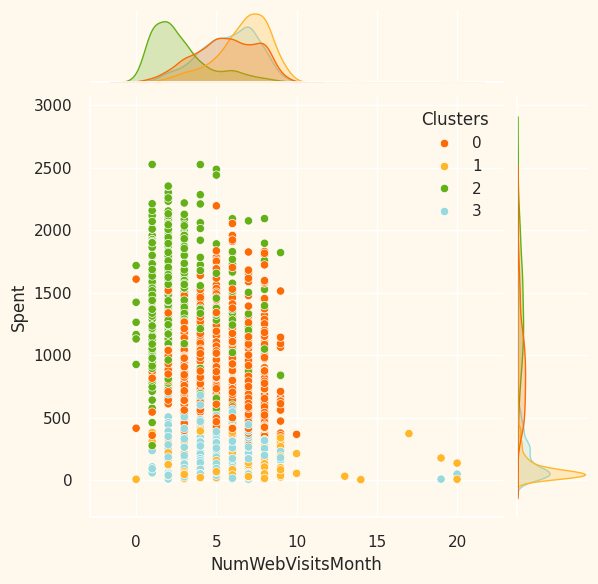

In [ ]:
#for more details on the purchasing style
Places =["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",  "NumWebVisitsMonth"]

for i in Places:
    plt.figure()
    sns.jointplot(x=data[i],y = data["Spent"],hue=data["Clusters"], palette= pal)
    plt.show()

<a id="8"></a>
# <p style="background-color:#682F2F;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">7. PROFILING</p>

- 군집화 완료: 고객 데이터를 군집화하여 구매 습관을 분석함.
- 목표:
    - 각 군집에 속한 고객의 특성을 분석.
    - 이를 통해 "스타 고객"과 "추가적인 관심이 필요한 고객"을 식별.
- 프로파일링:
    - 고객 개인 특성을 나타내는 주요 지표(특징)를 군집별로 시각화.
    - 이 데이터를 바탕으로 결론 도출.
- 결론:
분석 결과를 통해 리테일 매장의 마케팅 팀이 각 고객군에 맞는 전략을 세울 수 있도록 지원.

<Figure size 800x550 with 0 Axes>

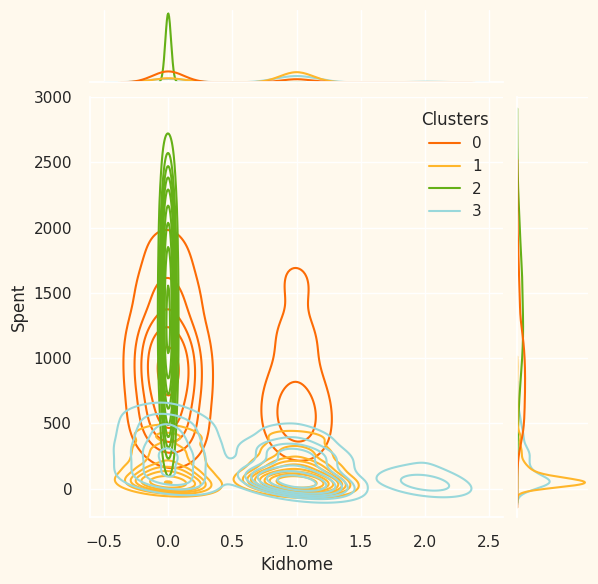

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1883: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(x=self.x, ax=self.ax_marg_x, **kwargs)


<Figure size 800x550 with 0 Axes>

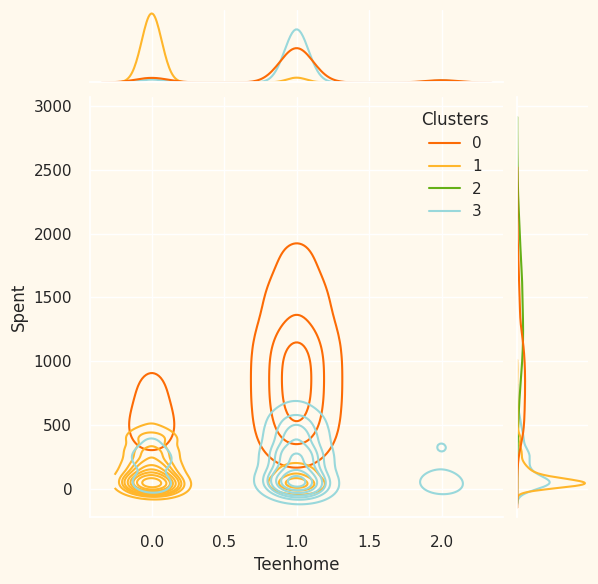

<Figure size 800x550 with 0 Axes>

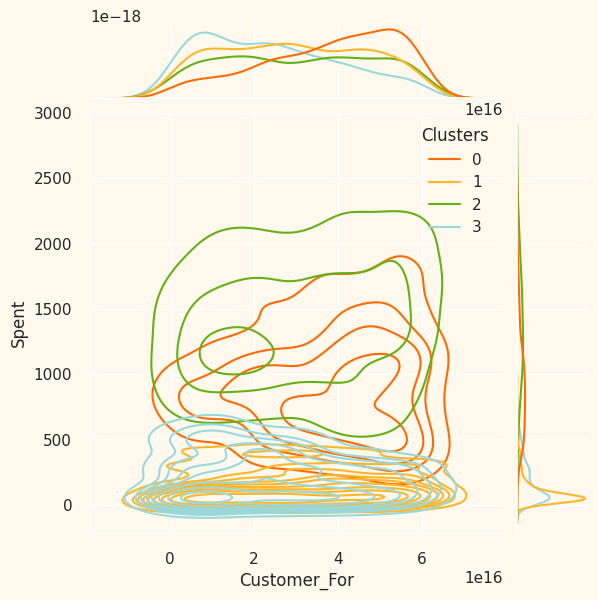

<Figure size 800x550 with 0 Axes>

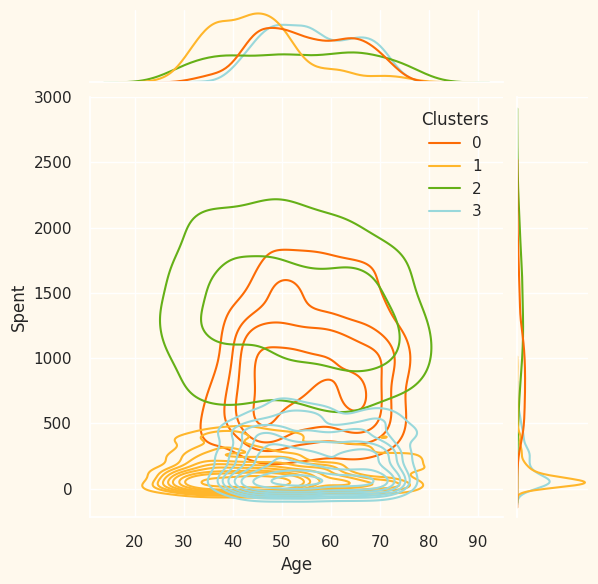

<Figure size 800x550 with 0 Axes>

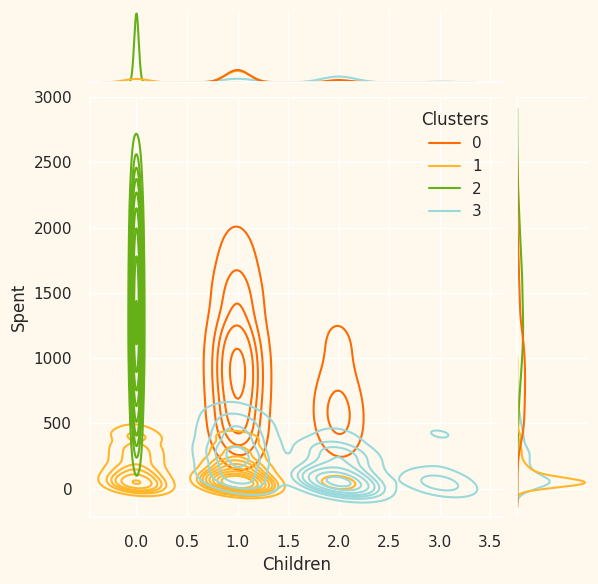

<Figure size 800x550 with 0 Axes>

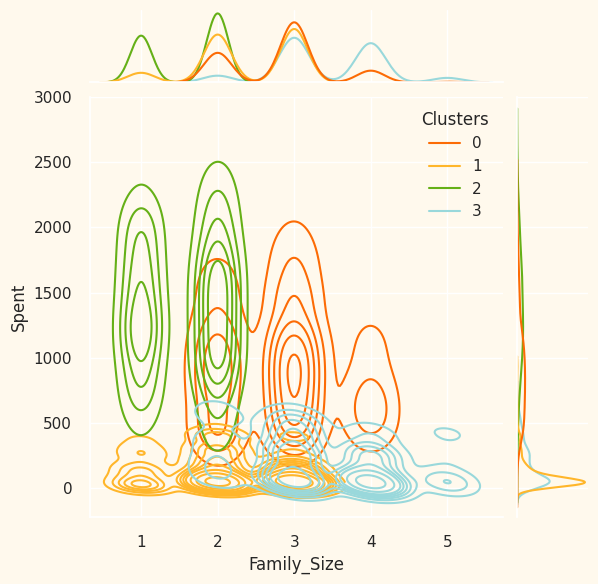

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1883: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(x=self.x, ax=self.ax_marg_x, **kwargs)


<Figure size 800x550 with 0 Axes>

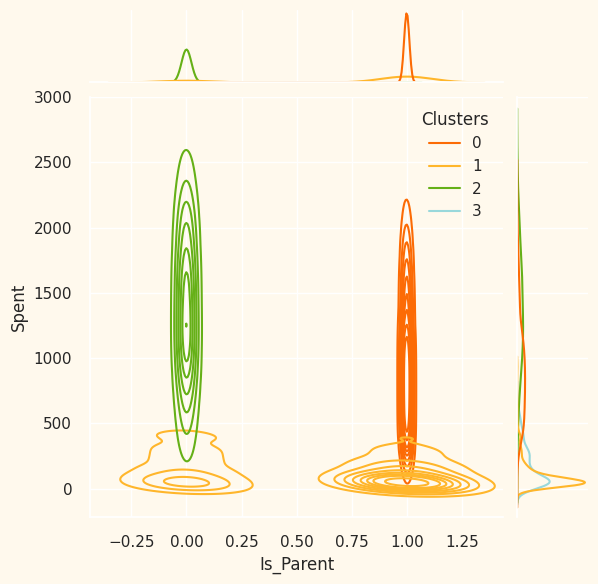

<Figure size 800x550 with 0 Axes>

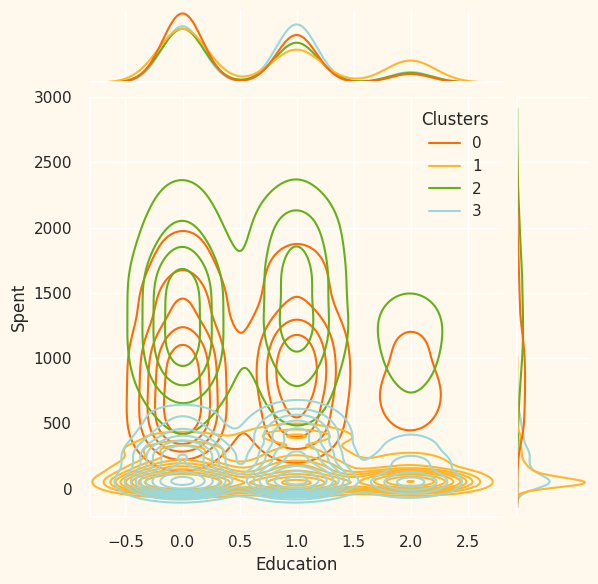

<Figure size 800x550 with 0 Axes>

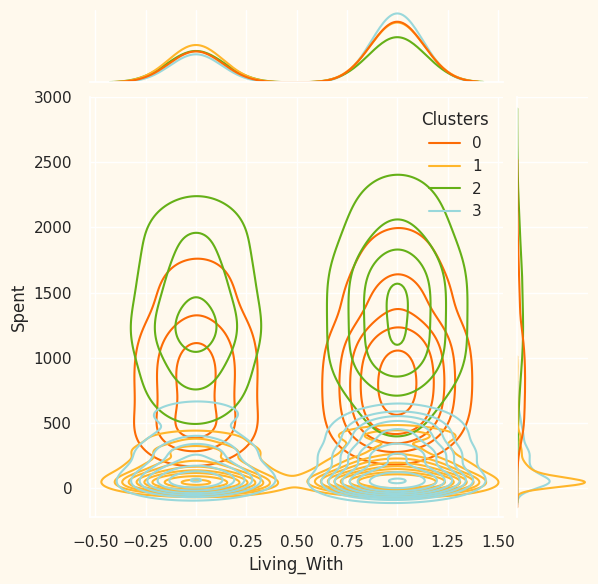

In [ ]:
Personal = [ "Kidhome","Teenhome","Customer_For", "Age", "Children", "Family_Size", "Is_Parent", "Education","Living_With"]

for i in Personal:
    plt.figure()
    sns.jointplot(x=data[i], y=data["Spent"], hue =data["Clusters"], kind="kde", palette=pal)
    plt.show()


#### 1. Living With (거주 형태)

- **군집 0**: 혼자 사는 경우가 많고, 높은 지출을 보입니다. 이는 개인 소비가 많고 자녀가 없는 성향을 나타냅니다.
- **군집 1**: 가족과 함께 사는 경우가 많으며, 높은 지출을 유지합니다. 가족을 위한 소비가 반영된 결과입니다.
- **군집 2**: 혼자 사는 경우가 많고, 낮은 지출을 보입니다. 가성비를 중시하며 소비가 적습니다.
- **군집 3**: 혼자 또는 가족과 함께 사는 경우가 있으며, 높은 지출을 보입니다. 비효율적인 소비 패턴이 나타날 수 있습니다.

### 종합적인 페르소나 분석

1. **군집 0: 고소득 개인 소비자**
   - **특징**:
     - 높은 지출과 평균 소득을 가진 중장년층으로, 혼자 사는 경우가 많습니다.
     - 다양한 구매 경로(웹, 카탈로그, 매장)를 활용하며, 브랜드 충성도가 높습니다.
     - 교육 수준이 높고, 자녀가 없는 경향이 있습니다.
   - **전략**: 고급 제품 및 서비스 제공, 맞춤형 프로모션으로 충성 고객으로 발전시킬 수 있도록 합니다.

2. **군집 1: 고소득 가족 소비자**
   - **특징**:
     - 고소득 고지출 소비자로, 가족과 함께 사는 경우가 많습니다.
     - 품질 높은 제품에 대한 수요가 크며, 다양한 구매 경로를 활용합니다.
     - 부모인 경우가 많고, 교육 수준도 높습니다.
   - **전략**: 가족을 위한 고급 제품 및 서비스 제공, 맞춤형 고급 프로모션을 통해 고객 충성도 강화.

3. **군집 2: 저소득 가성비 소비자**
   - **특징**:
     - 낮은 소득 저지출 소비자로, 혼자 사는 경우가 많습니다.
     - 가성비를 중시하며, 모든 구매 경로에서 활동이 적습니다.
     - 교육 수준이 낮은 경향이 있습니다.
   - **전략**: 할인 및 혜택 중심의 마케팅 전략 수립, 저렴한 제품을 강조하여 관심을 끌 수 있도록 합니다.

4. **군집 3: 소득 대비 높은 지출 소비자**
   - **특징**:
     - 소득 대비 높은 지출을 하는 소비자로, 혼자 또는 가족과 함께 사는 경우가 많습니다.
     - 자녀가 있을 가능성이 높고, 비효율적인 소비 패턴을 보입니다.
     - 재정 관리가 필요한 고객층입니다.
   - **전략**: 재정 상담 서비스 및 예산 관리 툴을 제공하여 고객의 재정 건전성을 높이는 방향으로 접근합니다.

<a id="6"></a>
# <p style="background-color:#682F2F;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">8. CLUSTERING : K-means clustering</p>

**Steps involved in the Clustering**
1. 실루엣 계수
2. 최적 군집 개수 선정
3. 군집화: Kmeans


#### 필요 함수

In [ ]:
### 여러개의 클러스터링 갯수를 List로 입력 받아 각각의 실루엣 계수를 면적으로 시각화한 함수 작성
def visualize_silhouette_kmeans(cluster_lists, X_features):

    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import math

    # 입력값으로 클러스터링 갯수들을 리스트로 받아서, 각 갯수별로 클러스터링을 적용하고 실루엣 개수를 구함
    n_cols = len(cluster_lists)

    # plt.subplots()으로 리스트에 기재된 클러스터링 수만큼의 sub figures를 가지는 axs 생성
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)

    # 리스트에 기재된 클러스터링 갯수들을 차례로 iteration 수행하면서 실루엣 개수 시각화
    for ind, n_cluster in enumerate(cluster_lists):

        # KMeans 클러스터링 수행하고, 실루엣 스코어와 개별 데이터의 실루엣 값 계산.
        clusterer = KMeans(n_clusters = n_cluster, max_iter=500, random_state=0)
        cluster_labels = clusterer.fit_predict(X_features)
        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)

        y_lower = 10
        axs[ind].set_title('Number of Cluster : '+ str(n_cluster)+'\n' \
                          'Silhouette Score :' + str(round(sil_avg,3)) )
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # Clear the yaxis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

        # 클러스터링 갯수별로 fill_betweenx( )형태의 막대 그래프 표현.
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels==i]
            ith_cluster_sil_values.sort()

            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values, \
                                facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10

        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

#### 최적 클러스터 수 결정: 실루엣 계수

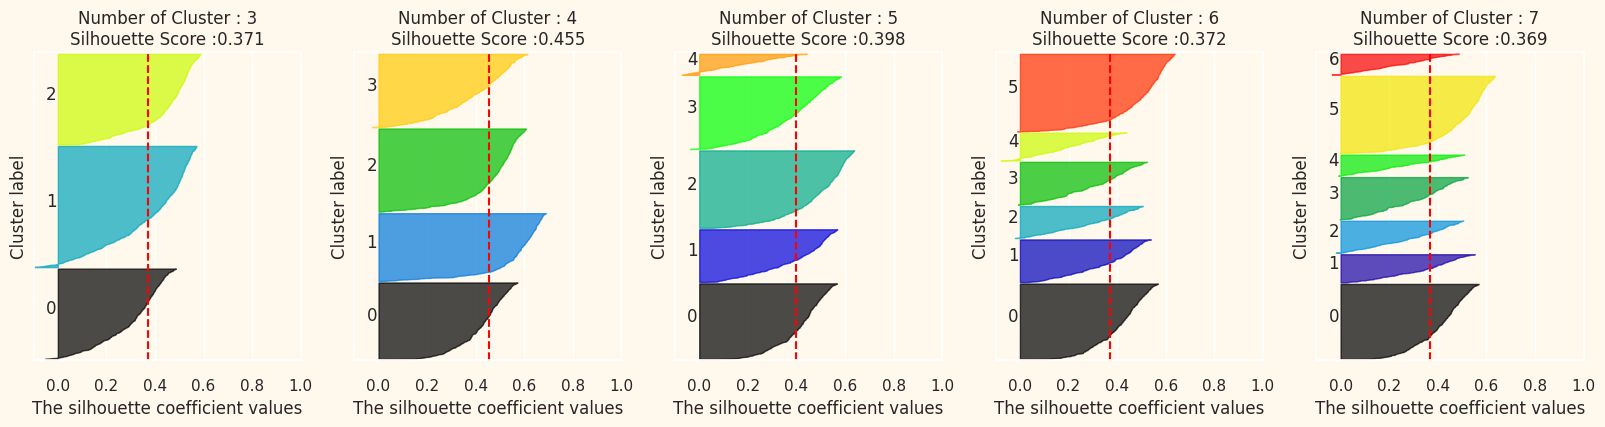

In [ ]:
visualize_silhouette_kmeans([3,4,5,6,7], PCA_ds)

#### 군집화: K-means

In [ ]:
# 군집화 수행
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=4, random_state=0)
labels = kmeans.fit_predict(PCA_ds)

In [ ]:
# 군집화 결과
PCA_ds2 = PCA_ds.copy()
PCA_ds2["Clusters"] = labels
#Adding the Clusters feature to the orignal dataframe.
data2 = data.copy()
data2["Clusters"]= labels

In [ ]:
PCA_ds["Clusters2"] = labels
#Adding the Clusters feature to the orignal dataframe.
data["Clusters2"]= labels

In [ ]:
PCA_ds[(PCA_ds['Clusters'] == 0) & (PCA_ds['Clusters2'] != 3)]
PCA_ds[(PCA_ds['Clusters'] == 1) & (PCA_ds['Clusters2'] != 2)]

,col1,col2,col3,Clusters,Clusters2
511,1.228660,-2.285713,-1.239600,1,1
578,1.351074,-2.182152,-1.270059,1,1
806,1.374564,-1.950188,-0.090968,1,1
999,1.478806,-1.736823,-1.841329,1,1
1425,1.130509,-2.030744,-1.695121,1,1
1485,1.636335,-1.734425,-1.223190,1,1
1567,1.289397,-2.179802,-1.947181,1,1


In [ ]:
data["Clusters"].value_counts()

,count
Clusters,
1,598
3,563
0,556
2,495


In [ ]:
data["Clusters2"].value_counts()

,count
Clusters2,
2,612
0,563
3,538
1,499


#### 군집 결과 확인: scatter plot

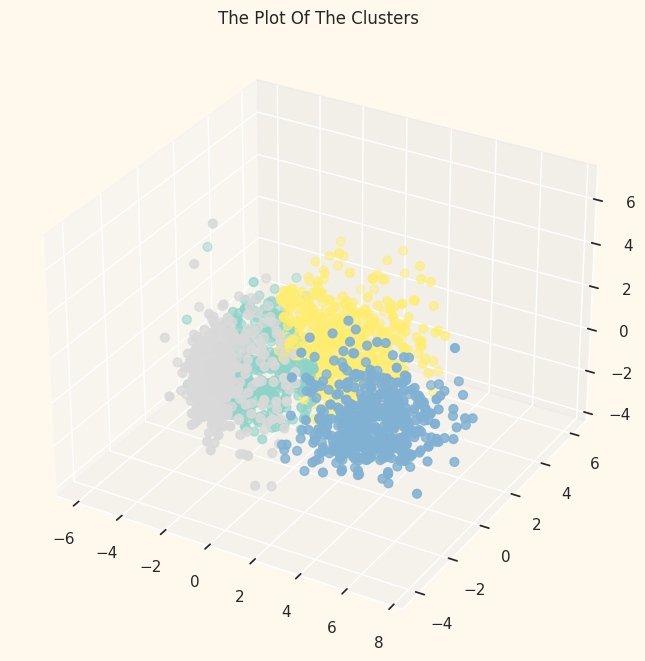

In [ ]:
#Plotting the clusters
fig = plt.figure(figsize=(10,8))
ax = plt.subplot(111, projection='3d', label="bla")
ax.scatter(x, y, z, s=40, c=PCA_ds2["Clusters"], marker='o', cmap = cmap )
ax.set_title("The Plot Of The Clusters")
plt.show()

<Figure size 800x550 with 0 Axes>

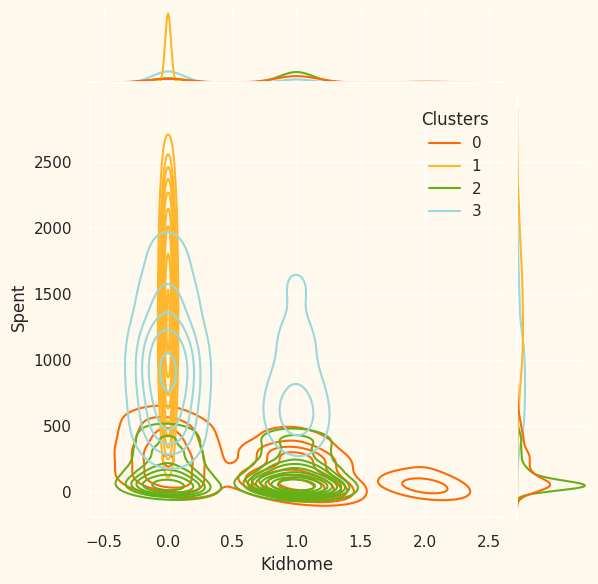

<Figure size 800x550 with 0 Axes>

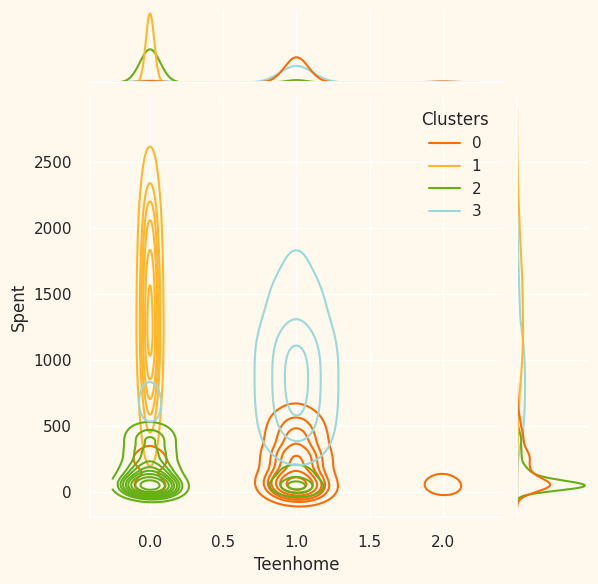

<Figure size 800x550 with 0 Axes>

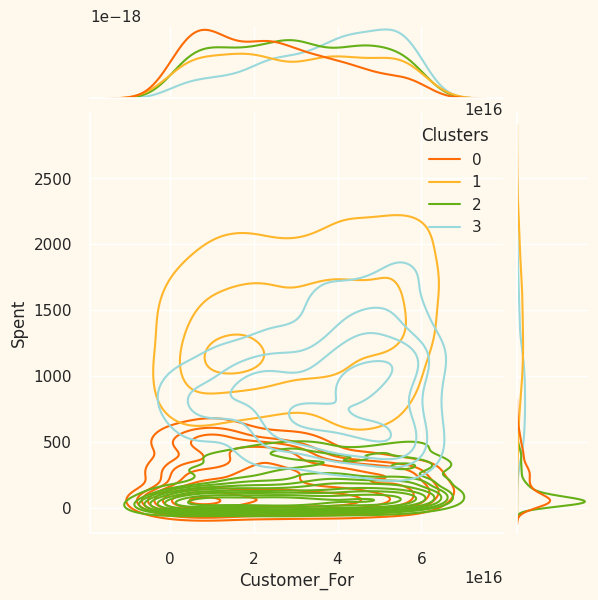

<Figure size 800x550 with 0 Axes>

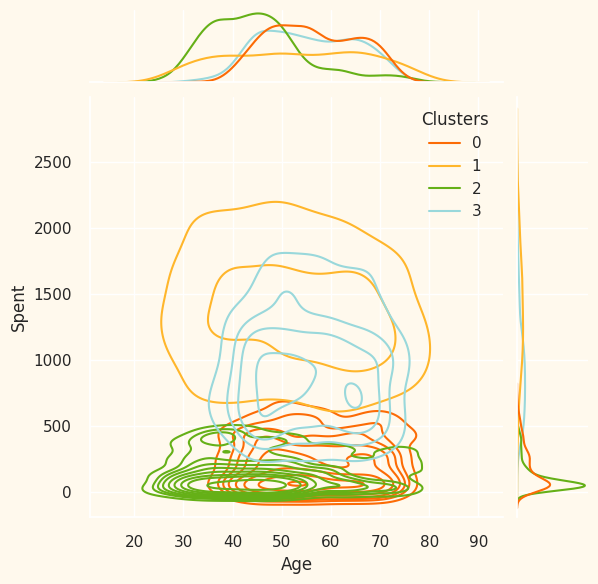

<Figure size 800x550 with 0 Axes>

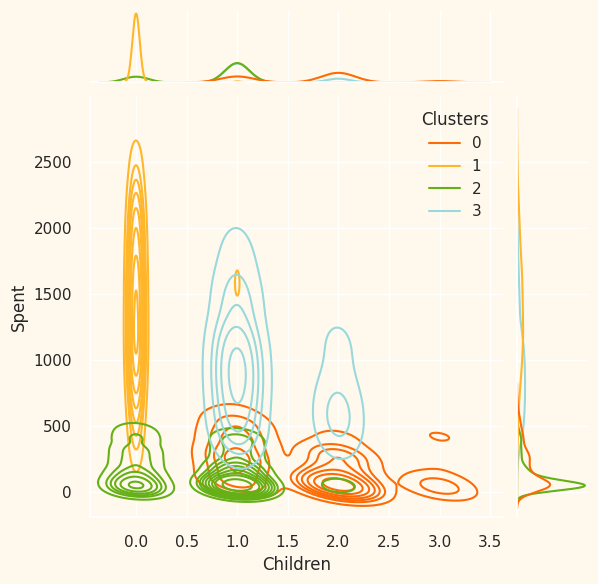

<Figure size 800x550 with 0 Axes>

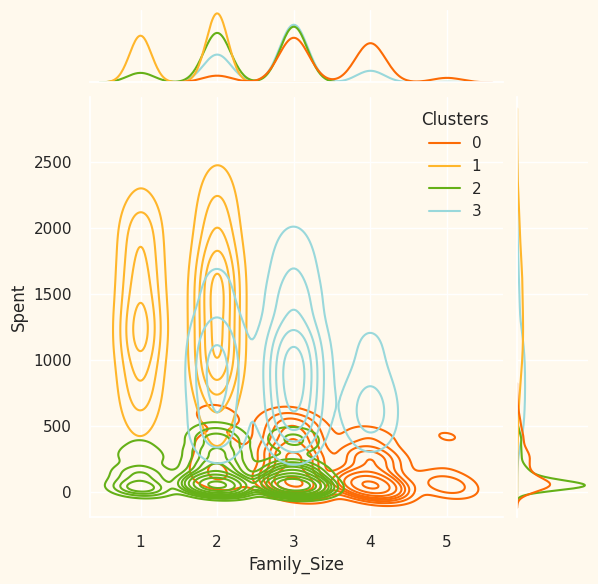

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:1883: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(x=self.x, ax=self.ax_marg_x, **kwargs)


<Figure size 800x550 with 0 Axes>

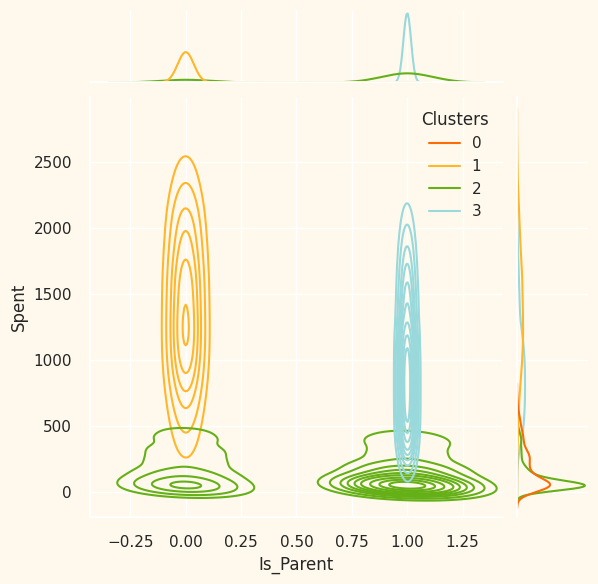

<Figure size 800x550 with 0 Axes>

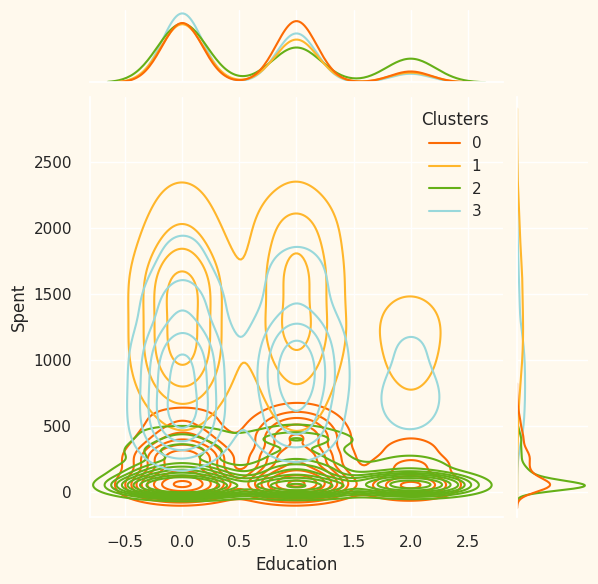

<Figure size 800x550 with 0 Axes>

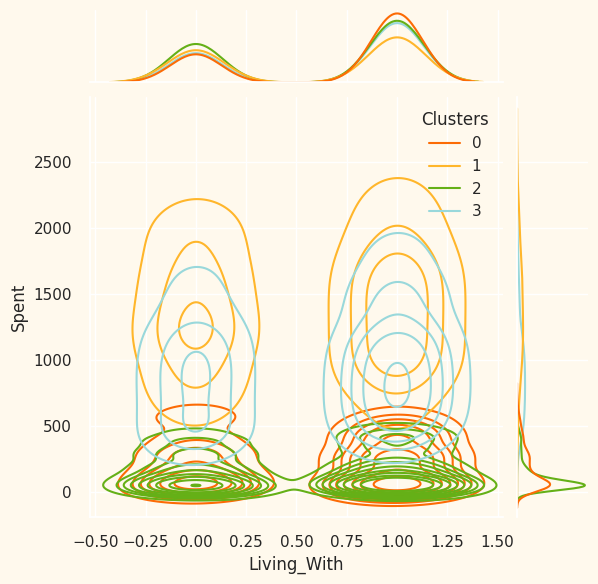

In [ ]:
Personal = [ "Kidhome","Teenhome","Customer_For", "Age", "Children", "Family_Size", "Is_Parent", "Education","Living_With"]

for i in Personal:
    plt.figure()
    sns.jointplot(x=data2[i], y=data2["Spent"], hue =data2["Clusters"], kind="kde", palette=pal)
    plt.show()


<a id="7"></a>
# <p style="background-color:#682F2F;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">9. EVALUATING MODELS : Kmeans</p>

**군집별 특성 파악**

#### 1. 군집의 분포 확인하기

<ipython-input-62-9910e01b9186>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl = sns.countplot(x=data2["Clusters"], palette= pal)


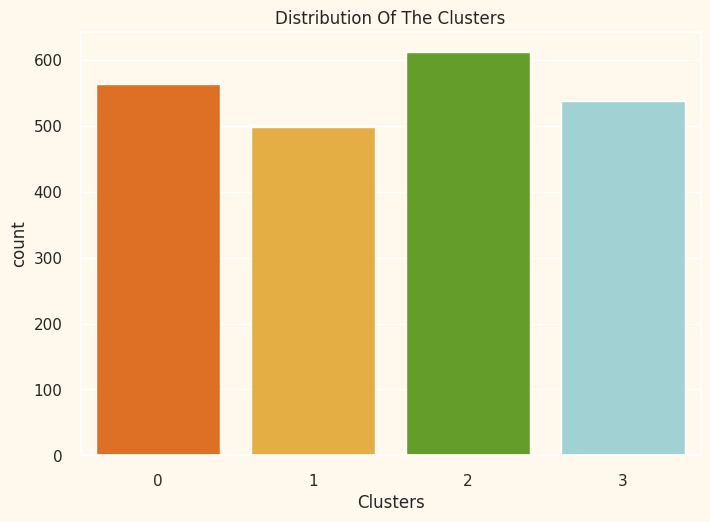

In [ ]:
#Plotting countplot of clusters
pl = sns.countplot(x=data2["Clusters"], palette= pal)
pl.set_title("Distribution Of The Clusters")
plt.show()

4개의 군집별 데이터 수가 균등한 편

#### 2. **군집별 소비금액과 소득의 관계**
* group 0: high spending & average income
* group 1: high spending & high income
* group 2: low spending & low income
* group 3: high spending & low income  


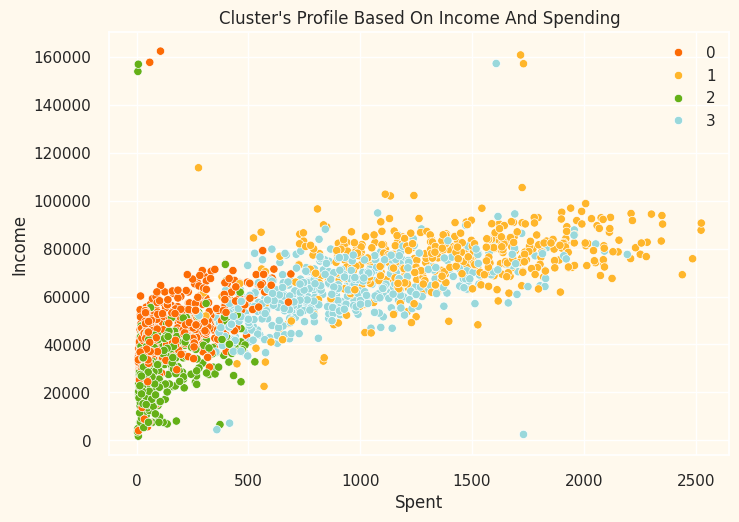

In [ ]:
pl = sns.scatterplot(data = data2,x=data2["Spent"], y=data2["Income"],hue=data2["Clusters"], palette= pal)
pl.set_title("Cluster's Profile Based On Income And Spending")
plt.legend()
plt.show()

#### 3. 군집별 소비금액 분포
: Wines, Fruits, Meat, Fish, Sweets and Gold 품목에 대한

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 56.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 70.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3399: UserWarning: 13.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
<ipython-input-64-440b2fff1c99>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl=sns.boxenplot(x=data2["Clusters"], y=data2["Spent"], palette=pal)
/usr/local/lib/python3.10/dist-packages/seaborn/

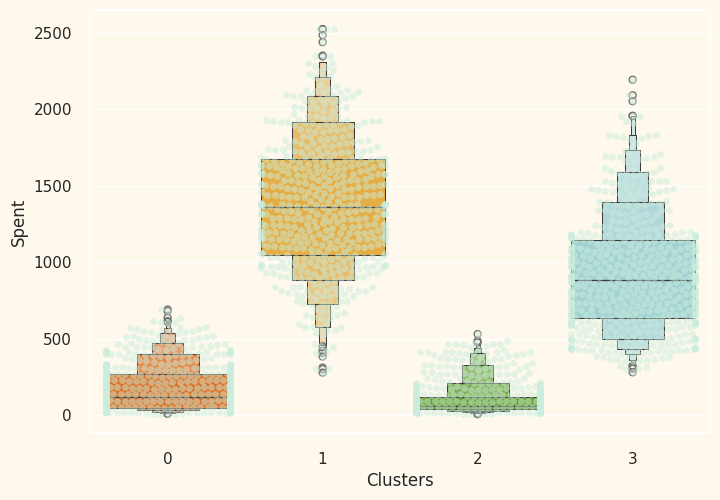

In [ ]:
plt.figure()
pl=sns.swarmplot(x=data2["Clusters"], y=data2["Spent"], color= "#CBEDDD", alpha=0.5 )
pl=sns.boxenplot(x=data2["Clusters"], y=data2["Spent"], palette=pal)
plt.show()

- 군집 2가 가장 큰 고객, 그 뒤는 군집 0이 따라옴
- 해당 카테고리에 대한 각 군집별 마케팅 전략 수립 가능

#### 4. 군집별 프로모션 관리를 위한 분석

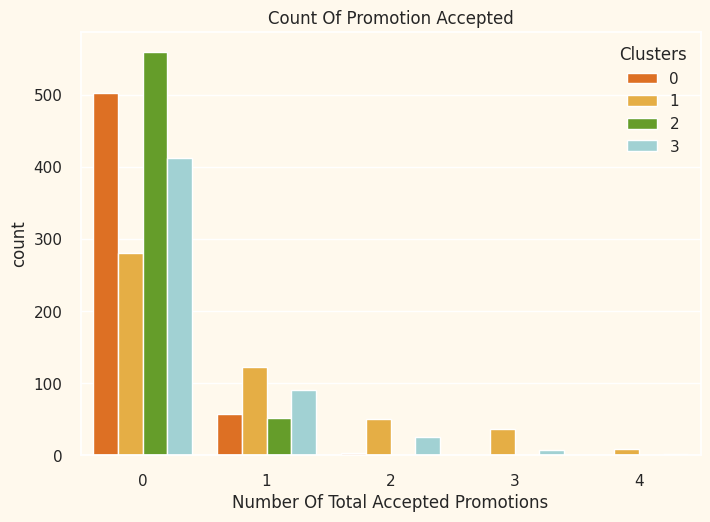

In [ ]:
#수락한 프로모션 갯수
data2["Total_Promos"] = data2["AcceptedCmp1"]+ data2["AcceptedCmp2"]+ data2["AcceptedCmp3"]+ data2["AcceptedCmp4"]+ data2["AcceptedCmp5"]
# 시각화
plt.figure()
pl = sns.countplot(x=data2["Total_Promos"],hue=data2["Clusters"], palette= pal)
pl.set_title("Count Of Promotion Accepted")
pl.set_xlabel("Number Of Total Accepted Promotions")
plt.show()

- 현재의 프로모션 성과는 크게 좋지 않음
- 모든 군집이 0에 가장 많이 분포

<ipython-input-66-0692bde92fb8>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  pl=sns.boxenplot(y=data2["NumDealsPurchases"],x=data2["Clusters"], palette= pal)


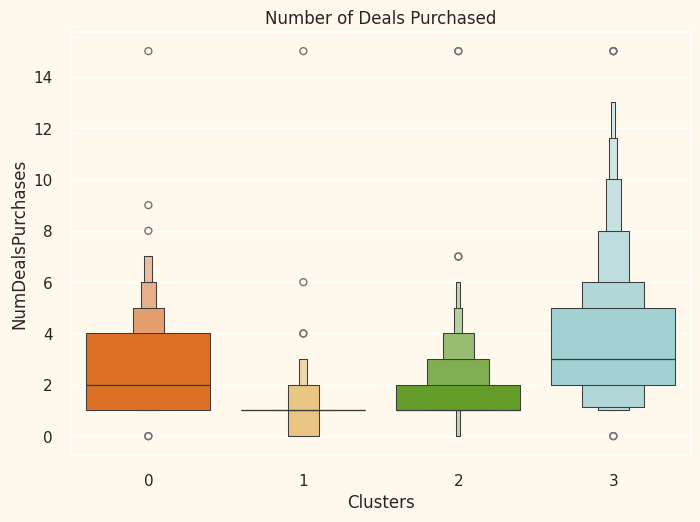

In [ ]:
#Plotting the number of deals purchased
plt.figure()
pl=sns.boxenplot(y=data2["NumDealsPurchases"],x=data2["Clusters"], palette= pal)
pl.set_title("Number of Deals Purchased")
plt.show()

- 프로모션 결과와 달리 거래 횟수는 괜찮음
    - cluster 0 and cluster 3에서 성과가 괜찮음 (이유는 모르겠음...)
    - cluster 1은 좋은 편은 아님
    - cluster 2를 끌어당길만한 것이 매우 부족해보임(제일 성과가 안좋다는 뜻)


<Figure size 800x550 with 0 Axes>

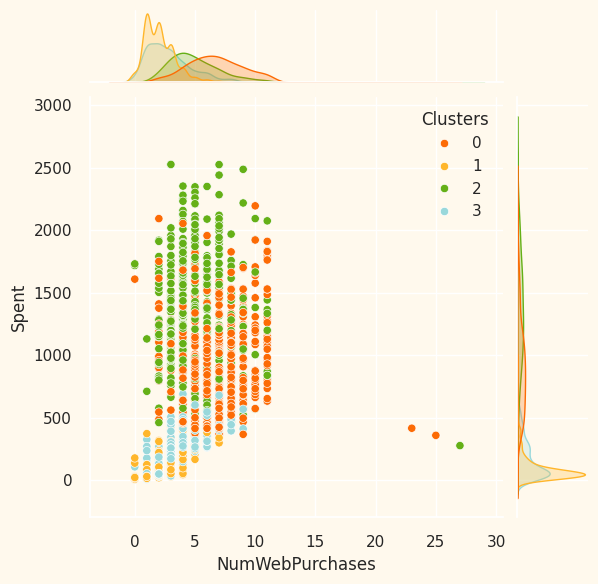

<Figure size 800x550 with 0 Axes>

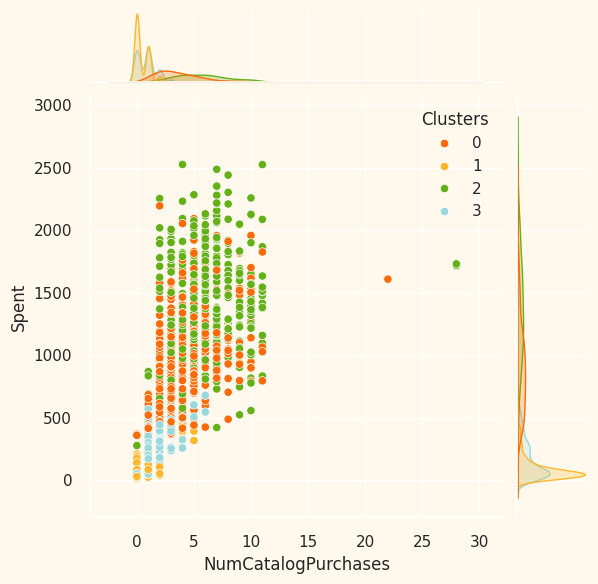

<Figure size 800x550 with 0 Axes>

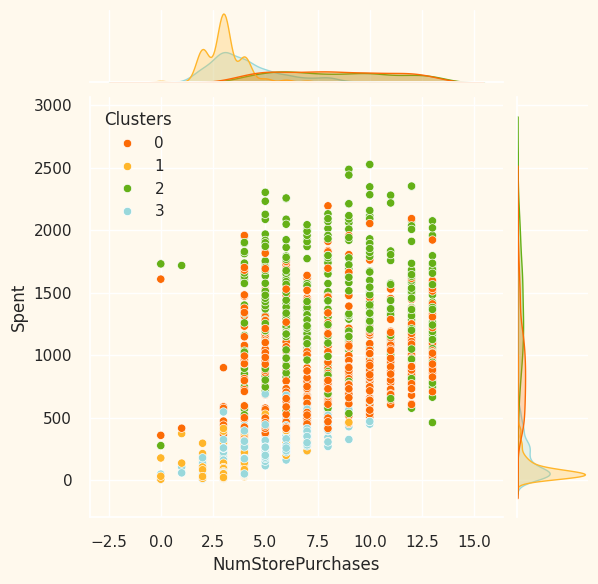

<Figure size 800x550 with 0 Axes>

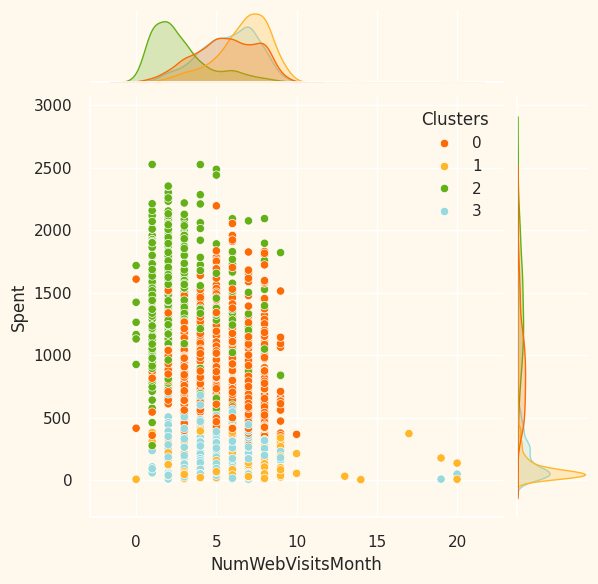

In [ ]:
#for more details on the purchasing style
Places =["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",  "NumWebVisitsMonth"]

for i in Places:
    plt.figure()
    sns.jointplot(x=data[i],y = data["Spent"],hue=data["Clusters"], palette= pal)
    plt.show()

<a id="8"></a>
# <p style="background-color:#682F2F;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">10. PROFILING</p>

- 군집화 완료: 고객 데이터를 군집화하여 구매 습관을 분석함.
- 목표:
    - 각 군집에 속한 고객의 특성을 분석.
    - 이를 통해 "스타 고객"과 "추가적인 관심이 필요한 고객"을 식별.
- 프로파일링:
    - 고객 개인 특성을 나타내는 주요 지표(특징)를 군집별로 시각화.
    - 이 데이터를 바탕으로 결론 도출.
- 결론:
분석 결과를 통해 리테일 매장의 마케팅 팀이 각 고객군에 맞는 전략을 세울 수 있도록 지원.

### 군집 분석

#### 1. 군집 0: "신중한 소비자"
- **소비 패턴**: 자녀가 없을 때 소비가 가장 높음. 고객 유지 기간이 짧고, 나이가 많을수록 소비가 증가하는 경향이 있음.
- **가족 구성**: 자녀 수가 적고, Teenhome과 Kidhome이 없는 경우 소비가 높음.
- **프로모션 수용**: 프로모션 수용이 낮고, 거래 구매 수가 많지 않음.
- **기타 특성**: 교육 수준이 낮고, 매장 및 웹 방문 수가 적은 편.

#### 2. 군집 1: "프리미엄 소비자"
- **소비 패턴**: 자녀가 있을 때 소비가 증가하며, 고객 유지 기간과 소비가 상관관계가 낮음. 나이와 관계없이 소비가 일정하게 유지됨.
- **가족 구성**: 자녀 수가 많을 때 소비가 높고, Teenhome이 있는 경우 소비가 높음.
- **프로모션 수용**: 프로모션 수용이 중간 수준이며, 거래 구매 수가 상대적으로 많음.
- **기타 특성**: 교육 수준이 높고, 매장 및 웹 방문 수가 평균 이상.

#### 3. 군집 2: "적극적인 소비자"
- **소비 패턴**: 고객 유지 기간이 길어질수록 소비가 줄어드는 경향. 자녀 수에 따라 소비가 변동하며, 나이가 많을수록 소비가 증가.
- **가족 구성**: 가족 규모가 중간 정도이며, 자녀 수가 많을 때 소비가 증가함.
- **프로모션 수용**: 높은 프로모션 수용과 거래 구매 수가 많음.
- **기타 특성**: 교육 수준이 중간이며, 웹 방문 수가 많은 경향.

#### 4. 군집 3: "경제적인 소비자"
- **소비 패턴**: 소비가 가장 낮고, 고객 유지 기간이 길어질수록 소비가 줄어드는 경향. 나이가 많을수록 소비가 낮음.
- **가족 구성**: 자녀가 많을수록 소비가 낮고, Teenhome 및 Kidhome이 있는 경우 소비가 더 낮아짐.
- **프로모션 수용**: 프로모션 수용이 낮고, 거래 구매 수가 적음.
- **기타 특성**: 교육 수준이 낮고, 매장 및 웹 방문 수가 적음.

### 종합 페르소나 정의

- **군집 0: "신중한 소비자"**
  - **특징**: 자녀가 없고, 소비에 신중함. 경제적인 선택을 중시하여 프로모션에 대한 관심이 적음.
  - **소비 경향**: 고정된 생활비를 소중히 여기며, 필요할 때만 소비함.

- **군집 1: "프리미엄 소비자"**
  - **특징**: 자녀가 있으며, 품질 높은 제품과 서비스를 선호. 다양한 프로모션을 수용하고, 거래를 많이 구매함.
  - **소비 경향**: 사회적 지위와 품질 중시, 적극적으로 소비하는 경향.

- **군집 2: "적극적인 소비자"**
  - **특징**: 자녀가 있으며, 소비에 대한 태도가 적극적임. 교육 수준이 중간이며, 웹 방문 수가 많음.
  - **소비 경향**: 다양한 제품에 대한 관심이 높고, 프로모션을 자주 활용함.

- **군집 3: "경제적인 소비자"**
  - **특징**: 자녀가 많고, 소비가 가장 낮은 경향. 경제적 안정성을 중시하며, 필수품 위주로 소비함.
  - **소비 경향**: 절약을 중시하고, 필요할 때만 구매하는 신중함.



<a id="8"></a>
# <p style="background-color:#682F2F;font-family:newtimeroman;color:#FFF9ED;font-size:150%;text-align:center;border-radius:10px 10px;">11. 기본 vs kmeans: 서로 비슷한 군집</p>

- 군집 0 - 군집 2(7)
- 군집 1 - 군집 1(6)
- 군집 2 - 군집 3(8)
- 군집 3 - 군집 0(5)


### 1. "신중한 소비자" (군집 0) vs. "저소득 가성비 소비자" (군집 7)

**공통점:**
- 자녀가 적거나 없는 경우가 많음.
- 소비에 신중하며, 가격을 중시함.
- 교육 수준이 낮고, 매장 및 웹 방문 수가 적음.

**차이점:**
- 군집 0은 소비가 상대적으로 높고, 프로모션 수용이 낮지만, 군집 7은 소비가 낮고 할인 및 혜택에 더 민감함.
- 군집 0은 고객 유지 기간이 짧은 경향이 있는 반면, 군집 7은 고객 유지 기간이 긴 경향이 있음.

---

### 2. "프리미엄 소비자" (군집 1) vs. "고소득 가족 소비자" (군집 6)

**공통점:**
- 자녀가 있으며, 가족과 함께 사는 경우가 많음.
- 품질 높은 제품과 서비스에 대한 선호가 강함.
- 교육 수준이 높고, 다양한 구매 경로를 활용함.

**차이점:**
- 군집 1은 프로모션 수용이 중간 수준인 반면, 군집 6은 고급 제품에 대한 수요가 크며 맞춤형 프로모션을 통해 고객 충성도를 강화하려는 전략을 가짐.
- 군집 1은 소비가 일정하게 유지되는 경향이 있는 반면, 군집 6은 가족을 위한 소비가 더 크게 증가함.

---

### 3. "적극적인 소비자" (군집 2) vs. "소득 대비 높은 지출 소비자" (군집 8)

**공통점:**
- 자녀 수에 따라 소비가 변동하며, 가족 규모가 중간 정도임.
- 프로모션 수용이 높고, 거래 구매 수가 많음.

**차이점:**
- 군집 2는 고객 유지 기간이 길어질수록 소비가 줄어드는 경향이 있는 반면, 군집 8은 비효율적인 소비 패턴을 보이고 재정 관리가 필요한 고객층으로 분류됨.
- 군집 2는 교육 수준이 중간인 반면, 군집 8은 소득 대비 높은 지출을 하는 경향이 있음.

---

### 4. "경제적인 소비자" (군집 3) vs. "고소득 개인 소비자" (군집 5)

**공통점:**
- 혼자 또는 가족과 함께 사는 경우가 많음.
- 소비가 낮은 경향이 있음.

**차이점:**
- 군집 3은 소비가 가장 낮고, 프로모션 수용이 낮은 반면, 군집 5는 높은 지출과 평균 소득을 가진 중장년층으로, 개인 소비가 많음.
- 군집 3은 필수품 위주로 소비하는 반면, 군집 5는 다양한 구매 경로를 활용하고 브랜드 충성도가 높은 경향이 있음.

---

### 종합 분석
이러한 매칭을 통해 각 군집의 소비 성향, 가족 구성, 교육 수준 등에서 유사성을 발견할 수 있었습니다. 각 군집의 소비 패턴에 따라 맞춤형 마케팅 전략을 세우는 것이 중요합니다. 예를 들어, "신중한 소비자"와 "저소득 가성비 소비자"는 가격 중심의 전략이 효과적일 수 있으며, "프리미엄 소비자"와 "고소득 가족 소비자"는 품질 중심의 마케팅이 필요합니다.

